In [ ]:
import stochpy
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import seaborn as sns

In [259]:






sim_number=50

/var/folders/59/vcwymf257_540j1np2_6zvgh0000gn/T/ipykernel_26781/2913240707.py:69: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


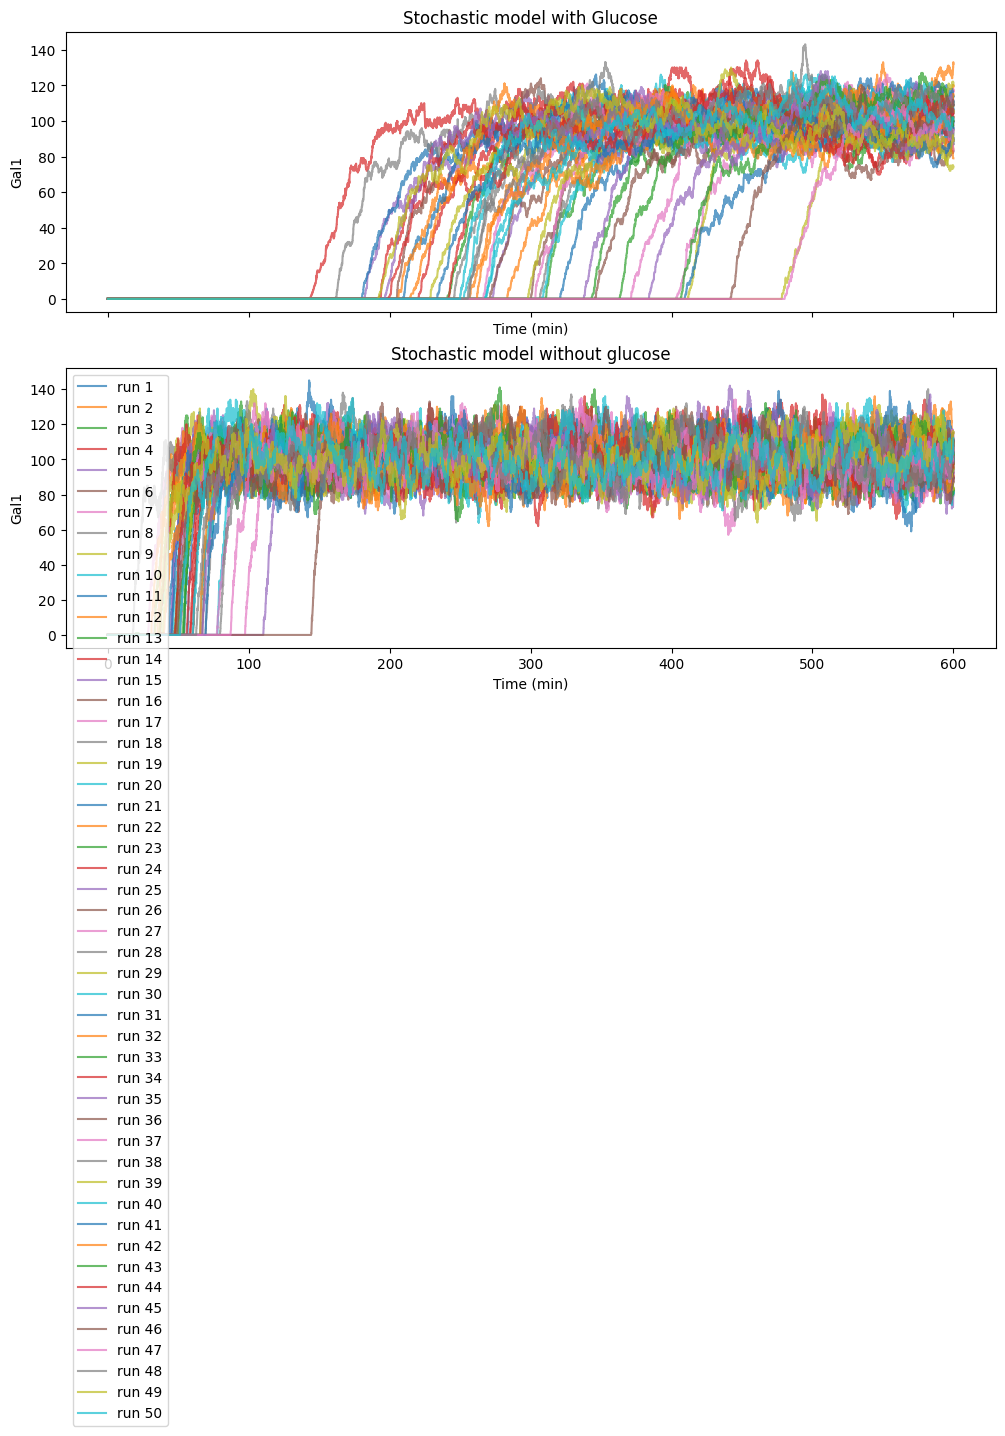

In [260]:
smod_glu = stochpy.SSA()
smod_glu.model_dir = os.getcwd()
smod_glu.Model(model_file="Gal_pathway_glu.psc")
smod_glu.DoStochSim(method="direct",end=600,mode="time",trajectories=sim_number,IsTrackPropensities=True)

raf_runs_data={}
glu_runs_data={}

first_times_glu=[]
first_times_raf=[]
raf_time={}
raf_gal_data={}
glu_time={}
glu_gal_data={}
fig, (ax1,ax2) = plt.subplots(2,1,figsize=(12,8), sharex=True)

for i in range(1, sim_number + 1):
    smod_glu.GetTrajectoryData(i)  # switch to trajectory i
    data = smod_glu.data_stochsim
    
    time = data.time
    glu_time[i-1]=time
    species = data.species_labels
    
    gal1_idx = species.index('Gal1')
    gal1=data.species[:, gal1_idx]
    glu_gal_data=gal1
    index = np.where(gal1 > 20)[0][0]
    first_time=time[index]
    first_times_glu.append(first_time)    

    ax1.plot(time, gal1, alpha=0.7,label = f'run {i}')

    

ax1.set_ylabel('Gal1')
ax1.set_xlabel('Time (min)')
ax1.set_title('Stochastic model with Glucose')

smod_raf = stochpy.SSA()
smod_raf.model_dir = os.getcwd()
smod_raf.Model(model_file="Gal_pathway_raf.psc")
smod_raf.DoStochSim(method="direct",end=600,mode="time",trajectories=sim_number)


for i in range(1, sim_number + 1):
    smod_raf.GetTrajectoryData(i)  # switch to trajectory i
    data = smod_raf.data_stochsim
    
    time = data.time
    raf_time[i]=time
    species = data.species_labels
    
    gal1_idx = species.index('Gal1')
    gal1=data.species[:, gal1_idx]

    raf_gal_data[i]=gal1
    index = np.where(gal1 > 20)[0][0]
    first_time=time[index]
    first_times_raf.append(first_time)
    ax2.plot(time, gal1, alpha=0.7,label=f"run {i}")
    

ax2.set_ylabel('Gal1')

ax2.set_xlabel('Time (min)')
ax2.set_title("Stochastic model without glucose")
ax2.legend()
plt.tight_layout()



In [261]:

noise_glu=np.var(first_times_glu)/(np.mean(first_times_glu)**2)

noise_noglu=np.var(first_times_raf)/(np.mean(first_times_raf)**2)

print(noise_glu,noise_noglu)


0.0790564407856759 0.1445582466668473
